In [26]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
plt.style.use("ggplot")

In [27]:
df = pd.read_csv("Yield Forecasting Data.csv")

dataset link:https://www.kaggle.com/datasets/patelris/crop-yield-prediction-dataset

The dataset contains the following columns:

Area: The country or region

Item: The crop type

Year: The year of the data entry

hg/ha_yield: The yield in hectograms per hectare

average_rain_fall_mm_per_year: The average annual rainfall in millimeters

pesticides_tonnes: The amount of pesticides used in tonnes

avg_temp: The average temperature in degrees Celsius

In [28]:
df.head()

,Area,Item,Year,hg/ha_yield,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp
0,Albania,Maize,1990,36613,1485,121.0,16.37
1,Albania,Potatoes,1990,66667,1485,121.0,16.37
2,Albania,"Rice, paddy",1990,23333,1485,121.0,16.37
3,Albania,Sorghum,1990,12500,1485,121.0,16.37
4,Albania,Soybeans,1990,7000,1485,121.0,16.37


In [29]:
df.tail()

,Area,Item,Year,hg/ha_yield,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp
28237,Zimbabwe,"Rice, paddy",2013,22581,657,2550.07,19.76
28238,Zimbabwe,Sorghum,2013,3066,657,2550.07,19.76
28239,Zimbabwe,Soybeans,2013,13142,657,2550.07,19.76
28240,Zimbabwe,Sweet potatoes,2013,22222,657,2550.07,19.76
28241,Zimbabwe,Wheat,2013,22888,657,2550.07,19.76


In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28242 entries, 0 to 28241
Data columns (total 7 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Area                           28242 non-null  object 
 1   Item                           28242 non-null  object 
 2   Year                           28242 non-null  int64  
 3   hg/ha_yield                    28242 non-null  int64  
 4   average_rain_fall_mm_per_year  28242 non-null  int64  
 5   pesticides_tonnes              28242 non-null  float64
 6   avg_temp                       28242 non-null  float64
dtypes: float64(2), int64(3), object(2)
memory usage: 1.5+ MB


In [31]:
df.isnull().sum()

Area                             0
Item                             0
Year                             0
hg/ha_yield                      0
average_rain_fall_mm_per_year    0
pesticides_tonnes                0
avg_temp                         0
dtype: int64

In [32]:
df.duplicated().sum()

2310

In [33]:
df.drop_duplicates(inplace=True)

In [34]:
df.duplicated().sum()

0

In [35]:
df.shape

(25932, 7)

In [36]:
df.describe()

,Year,hg/ha_yield,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp
count,25932.000000,25932.000000,25932.000000,25932.000000,25932.000000
mean,2001.556455,76978.132925,1146.836688,34782.573241,20.422251
std,7.055924,84647.605552,717.391098,57228.568244,6.439402
min,1990.000000,50.000000,51.000000,0.040000,1.300000
25%,1995.000000,19996.000000,593.000000,1597.000000,16.580000
50%,2001.000000,39530.000000,1083.000000,15373.000000,21.420000
75%,2008.000000,104168.000000,1668.000000,45620.000000,26.060000
max,2013.000000,501412.000000,3240.000000,367778.000000,30.650000


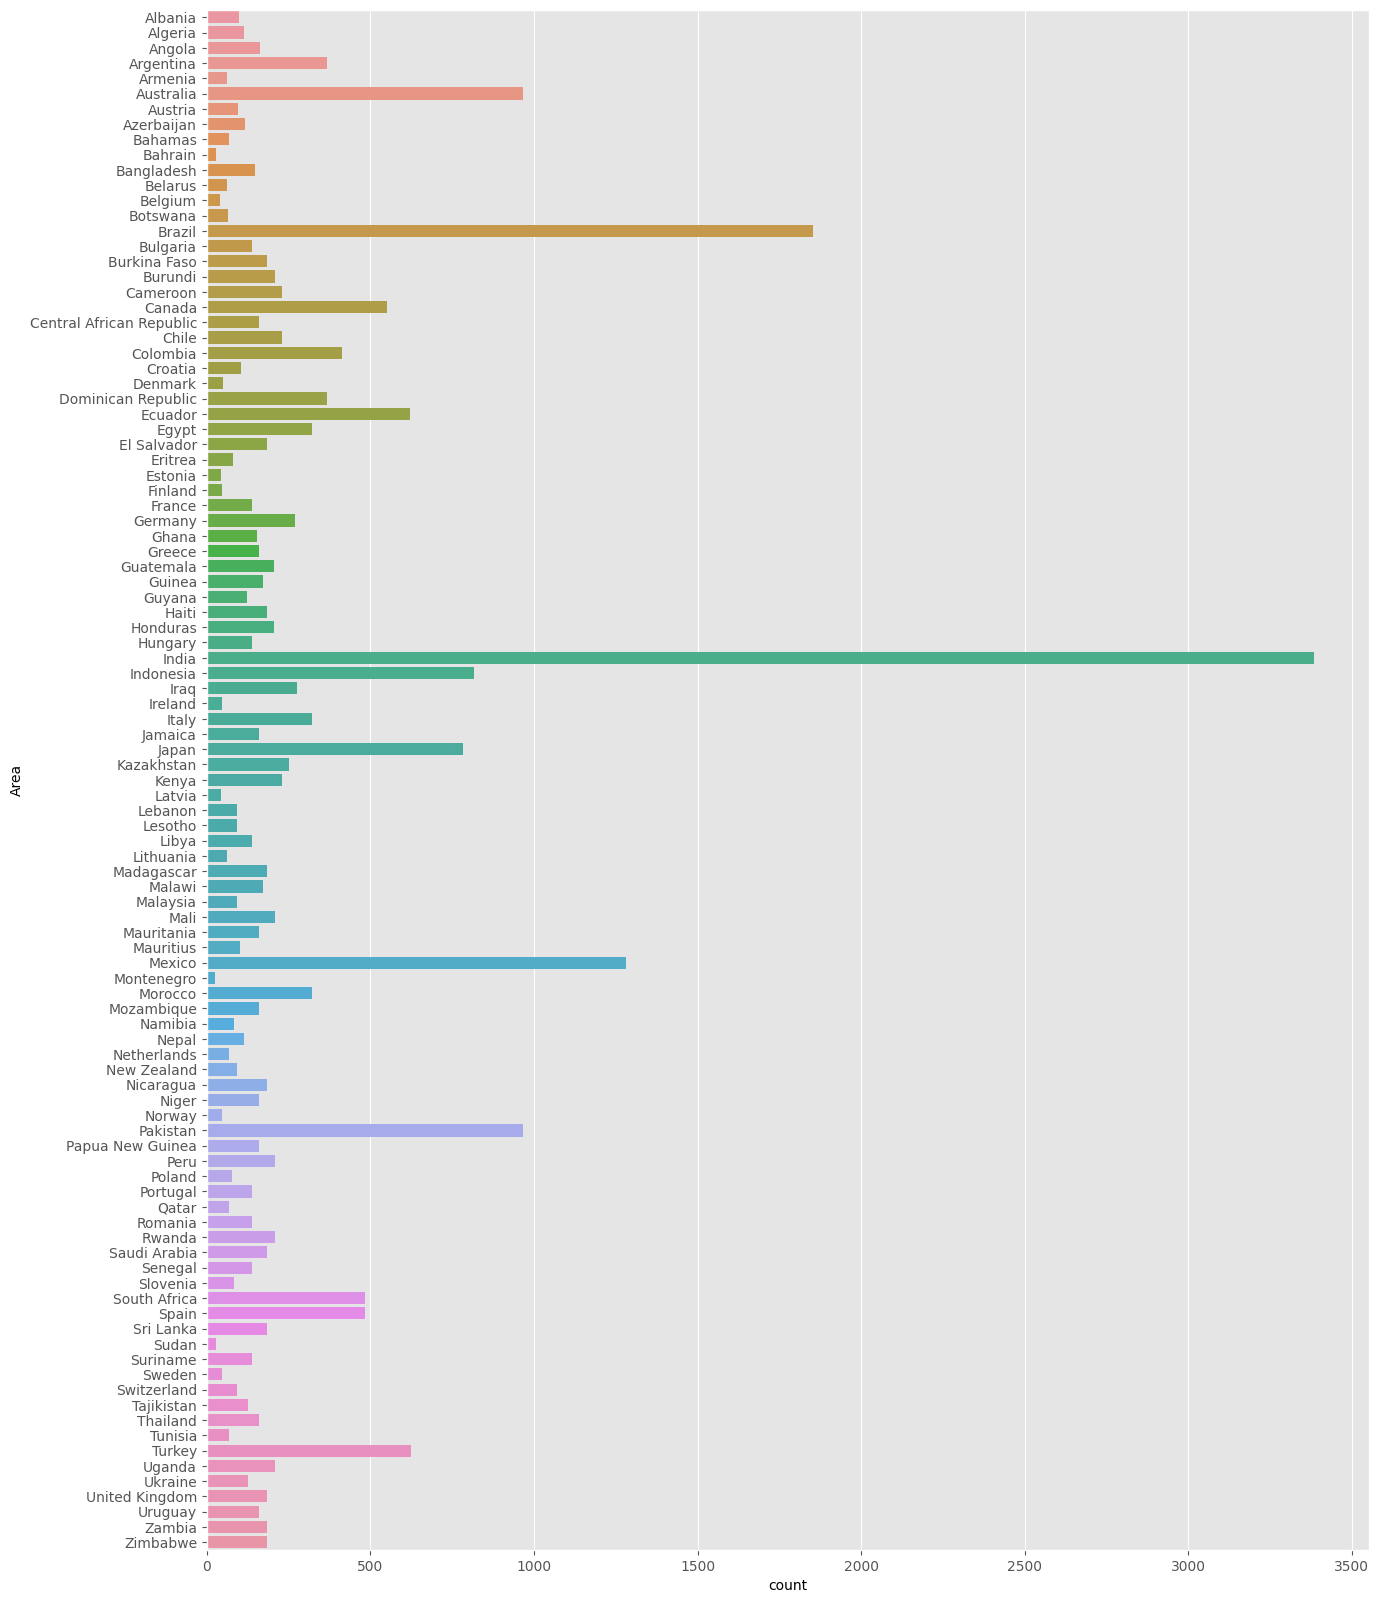

In [37]:
plt.figure(figsize=(15,20))
sns.countplot(y = df['Area'])
plt.show()

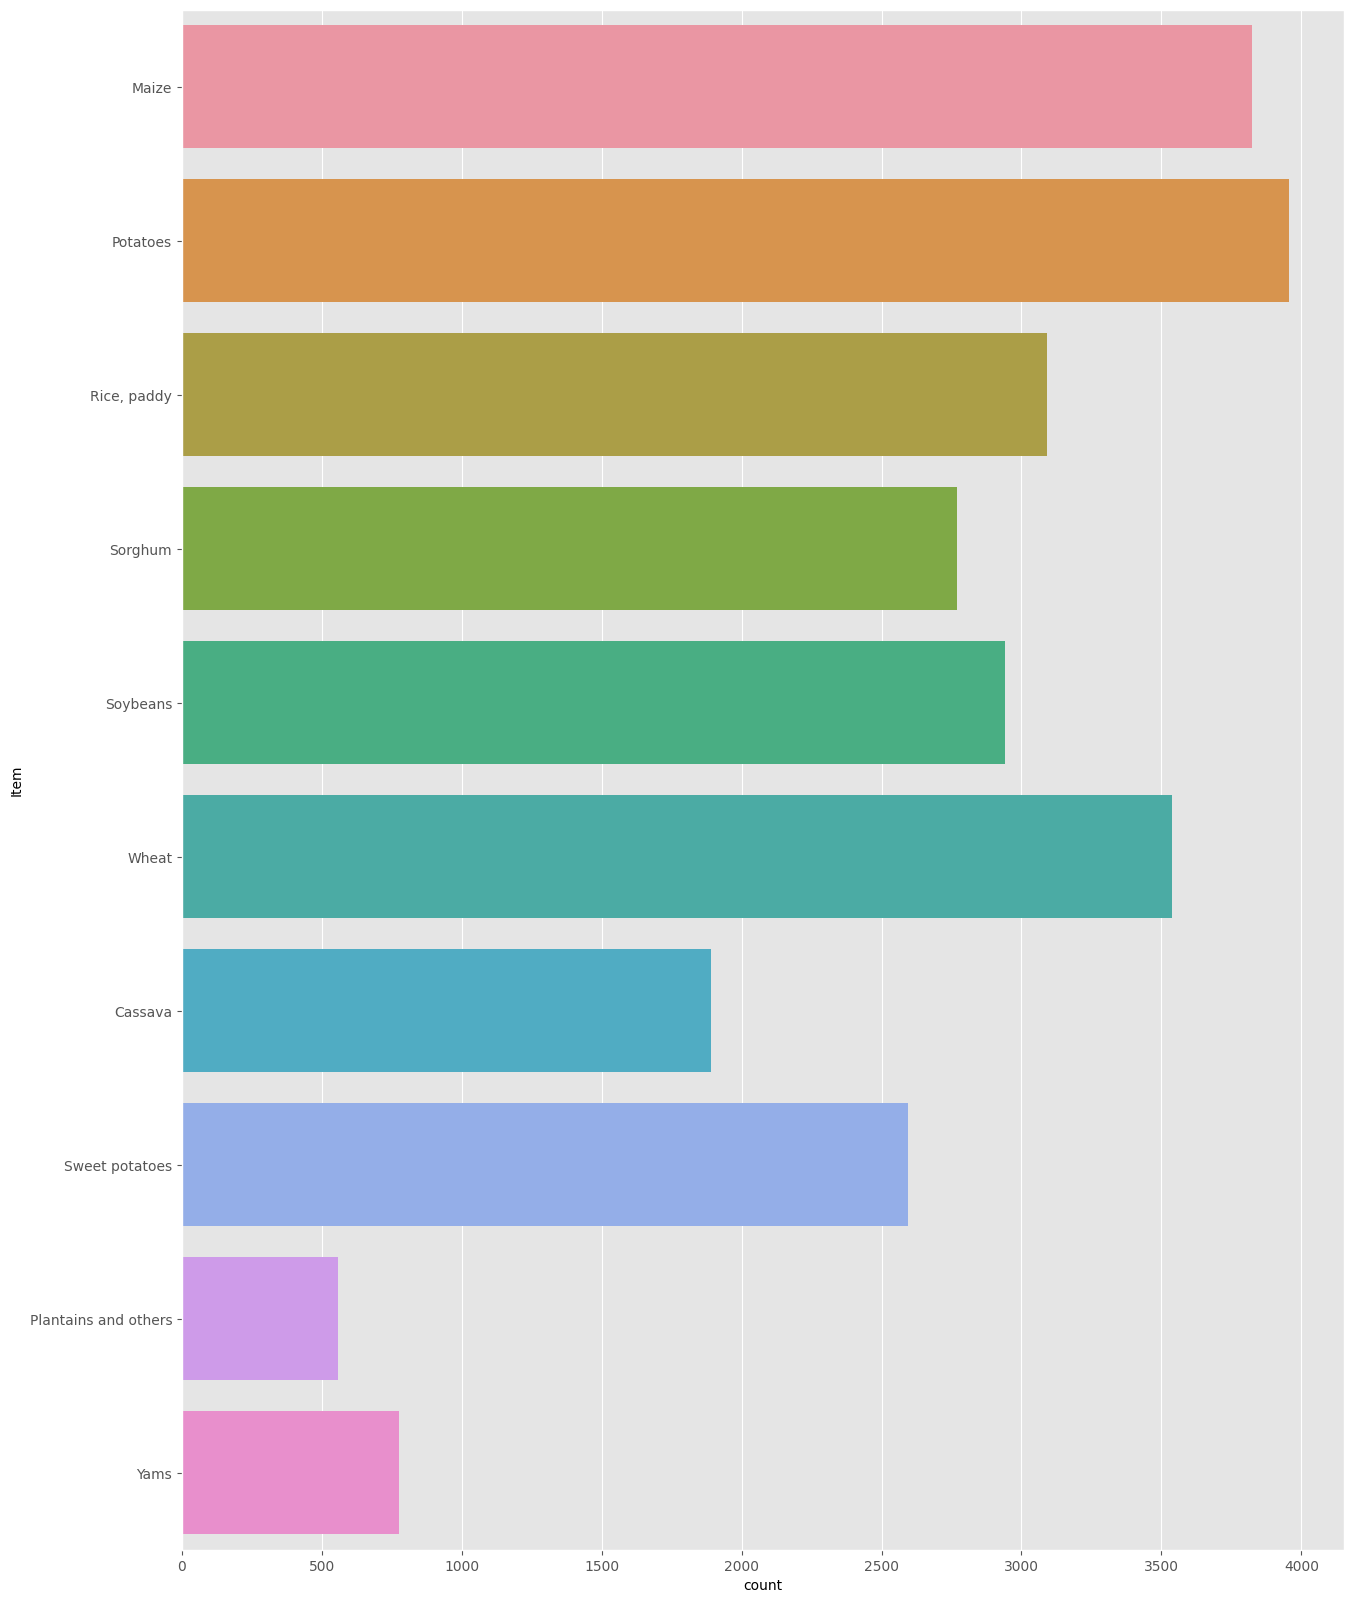

In [38]:
plt.figure(figsize=(15,20))
sns.countplot(y = df['Item'])
plt.show()

In [39]:
#label encoding the data.
from sklearn.preprocessing import LabelEncoder, StandardScaler
# Store original column names
original_columns = df.select_dtypes(include='object').columns

# Initialize LabelEncoder
label_encoders = {}

# Apply LabelEncoder to each categorical variable
for col in original_columns:
    label_encoders[col] = LabelEncoder()
    df[col] = label_encoders[col].fit_transform(df[col])

# Print the mapping between original categories and numerical labels
for col, encoder in label_encoders.items():
    print(f"Mapping for column '{col}':")
    for label, category in enumerate(encoder.classes_):
        print(f"Label {label}: {category}")

Mapping for column 'Area':
Label 0: Albania
Label 1: Algeria
Label 2: Angola
Label 3: Argentina
Label 4: Armenia
Label 5: Australia
Label 6: Austria
Label 7: Azerbaijan
Label 8: Bahamas
Label 9: Bahrain
Label 10: Bangladesh
Label 11: Belarus
Label 12: Belgium
Label 13: Botswana
Label 14: Brazil
Label 15: Bulgaria
Label 16: Burkina Faso
Label 17: Burundi
Label 18: Cameroon
Label 19: Canada
Label 20: Central African Republic
Label 21: Chile
Label 22: Colombia
Label 23: Croatia
Label 24: Denmark
Label 25: Dominican Republic
Label 26: Ecuador
Label 27: Egypt
Label 28: El Salvador
Label 29: Eritrea
Label 30: Estonia
Label 31: Finland
Label 32: France
Label 33: Germany
Label 34: Ghana
Label 35: Greece
Label 36: Guatemala
Label 37: Guinea
Label 38: Guyana
Label 39: Haiti
Label 40: Honduras
Label 41: Hungary
Label 42: India
Label 43: Indonesia
Label 44: Iraq
Label 45: Ireland
Label 46: Italy
Label 47: Jamaica
Label 48: Japan
Label 49: Kazakhstan
Label 50: Kenya
Label 51: Latvia
Label 52: Leban

In [40]:
df.corr()

,Area,Item,Year,hg/ha_yield,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp
Area,1.000000,0.001025,0.004447,0.004097,-0.190913,-0.294112,-0.038663
Item,0.001025,1.000000,0.001441,-0.221689,-0.069076,0.049431,-0.079012
Year,0.004447,0.001441,1.000000,0.091327,-0.006423,0.135127,0.013701
hg/ha_yield,0.004097,-0.221689,0.091327,1.000000,-0.004067,0.065523,-0.110400
average_rain_fall_mm_per_year,-0.190913,-0.069076,-0.006423,-0.004067,1.000000,0.161483,0.333694
pesticides_tonnes,-0.294112,0.049431,0.135127,0.065523,0.161483,1.000000,0.045577
avg_temp,-0.038663,-0.079012,0.013701,-0.110400,0.333694,0.045577,1.000000


In [41]:
df['hg/ha_yield'].sum()

1996196943

In [42]:
df.columns

Index(['Area', 'Item', 'Year', 'hg/ha_yield', 'average_rain_fall_mm_per_year',
       'pesticides_tonnes', 'avg_temp'],
      dtype='object')

In [43]:
col = ['Year','average_rain_fall_mm_per_year','pesticides_tonnes', 'avg_temp','Area', 'Item', 'hg/ha_yield']

In [44]:
df = df[col]

In [45]:
df.head()

,Year,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp,Area,Item,hg/ha_yield
0,1990,1485,121.0,16.37,0,1,36613
1,1990,1485,121.0,16.37,0,3,66667
2,1990,1485,121.0,16.37,0,4,23333
3,1990,1485,121.0,16.37,0,5,12500
4,1990,1485,121.0,16.37,0,6,7000


In [46]:
X = df.drop('hg/ha_yield', axis = 1)
y = df['hg/ha_yield']

In [47]:
# Normalize the features using StandardScaler
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [48]:
# Split the data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

In [49]:
X_train.shape, X_test.shape

((20745, 6), (5187, 6))

# ***RandomForestRegressor***

In [50]:
from sklearn.ensemble import RandomForestRegressor
# Initialize and train the Random Forest Regressor model
random_forest_model = RandomForestRegressor(n_estimators=100, random_state=42)
random_forest_model.fit(X_train, y_train)

# Now, let's evaluate the model on the test set
from sklearn.metrics import mean_squared_error, r2_score

# Predicting on the test set
y_pred = random_forest_model.predict(X_test)

# Evaluating the model performance
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error (MSE):", mse)
print("R-squared (R2):", r2)



Mean Squared Error (MSE): 120837643.25709778
R-squared (R2): 0.9833278890971301


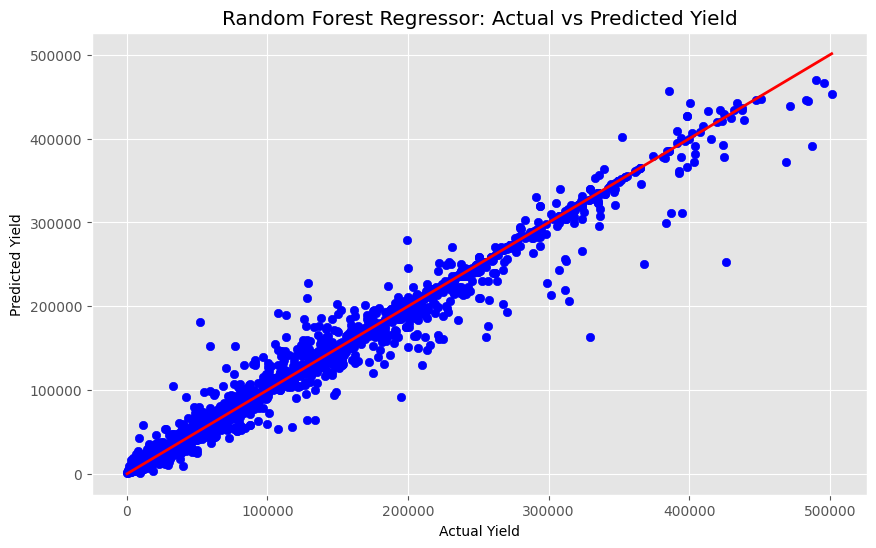

In [51]:
# If you want to visualize the predictions
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', lw=2)
plt.title("Random Forest Regressor: Actual vs Predicted Yield")
plt.xlabel("Actual Yield")
plt.ylabel("Predicted Yield")
plt.show()

In [52]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, SimpleRNN, Conv1D, MaxPooling1D, Flatten
from sklearn.metrics import classification_report, confusion_matrix


In [53]:

# Reshaping data for time-series models (LSTM and RNN)
X_train_lstm_rnn = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test_lstm_rnn = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

# LSTM

In [54]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.models import Sequential, load_model

# LSTM Model
lstm_model = Sequential()
lstm_model.add(LSTM(units=64, input_shape=(X_train_lstm_rnn.shape[1], 1)))
lstm_model.add(Dense(1))
lstm_model.compile(optimizer='adam', loss='mse')

# Train the LSTM model
lstm_model.fit(X_train_lstm_rnn, y_train, epochs=30, batch_size=32, validation_data=(X_test_lstm_rnn, y_test))



Epoch 1/30

649/649 [==============================] - 7s 6ms/step - loss: 13009827840.0000 - val_loss: 13385263104.0000
Epoch 2/30
649/649 [==============================] - 3s 5ms/step - loss: 13003034624.0000 - val_loss: 13378624512.0000
Epoch 3/30
649/649 [==============================] - 3s 5ms/step - loss: 12996598784.0000 - val_loss: 13372095488.0000
Epoch 4/30
649/649 [==============================] - 3s 4ms/step - loss: 12990238720.0000 - val_loss: 13365588992.0000
Epoch 5/30
649/649 [==============================] - 3s 4ms/step - loss: 12983897088.0000 - val_loss: 13359125504.0000
Epoch 6/30
649/649 [==============================] - 3s 4ms/step - loss: 12977568768.0000 - val_loss: 13352647680.0000
Epoch 7/30
649/649 [==============================] - 3s 4ms/step - loss: 12971238400.0000 - val_loss: 13346182144.0000
Epoch 8/30
649/649 [==============================] - 3s 4ms/step - loss: 12964917248.0000 - val_loss: 13339714560.0000
Epoch 9/30
649/649 [=================

In [55]:
# Save the model
lstm_model.save('lstm_model.h5')

C:\Users\0931\AppData\Roaming\Python\Python310\site-packages\keras\src\engine\training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [56]:
# Evaluate the models
lstm_predictions = lstm_model.predict(X_test_lstm_rnn)

163/163 [==============================] - 1s 2ms/step


In [57]:
# Evaluate using classification report and confusion matrix (for regression, we'll assess predictions)
lstm_class_report = classification_report(y_test, lstm_predictions.round())
print(lstm_class_report)

              precision    recall  f1-score   support

       200.0       0.00      0.00      0.00       1.0
       230.0       0.00      0.00      0.00       1.0
       500.0       0.00      0.00      0.00       1.0
       578.0       0.00      0.00      0.00       1.0
       811.0       0.00      0.00      0.00       1.0
       824.0       0.00      0.00      0.00       1.0
       849.0       0.00      0.00      0.00       1.0
       866.0       0.00      0.00      0.00       1.0
       973.0       0.00      0.00      0.00       1.0
      1123.0       0.00      0.00      0.00       1.0
      1242.0       0.00      0.00      0.00       1.0
      1256.0       0.00      0.00      0.00       0.0
      1317.0       0.00      0.00      0.00       1.0
      1448.0       0.00      0.00      0.00       1.0
      1449.0       0.00      0.00      0.00       1.0
      1541.0       0.00      0.00      0.00       1.0
      1573.0       0.00      0.00      0.00       1.0
      1706.0       0.00    

C:\Users\0931\AppData\Roaming\Python\Python310\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\0931\AppData\Roaming\Python\Python310\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\0931\AppData\Roaming\Python\Python310\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\

In [58]:
lstm_conf_matrix = confusion_matrix(y_test, lstm_predictions.round())
lstm_conf_matrix

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], dtype=int64)

In [59]:
def predict_yield(inputs, scaler):
    # Load the saved model
    model = load_model('lstm_model.h5')
    
    # Scale the inputs
    inputs_scaled = scaler.transform(np.array(inputs).reshape(1, -1))
    # Correctly reshape the inputs for the LSTM model
    inputs_final = np.reshape(inputs_scaled, (1, inputs_scaled.shape[1], 1))
    
    # Make a prediction
    prediction = model.predict(inputs_final)
    return prediction[0][0]

# Example input for prediction
example_input = [2021, 1000, 250, 25, 100, 2]  # Sample input features
predicted_yield = predict_yield(example_input, scaler)
print(f"Predicted Yield production is: {predicted_yield}")

C:\Users\0931\AppData\Roaming\Python\Python310\site-packages\sklearn\base.py:464: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


1/1 [==============================] - 1s 770ms/step
Predicted Yield production is: 1256.1324462890625


In [60]:
def predict_yield(inputs, scaler):
    # Load the saved model
    model = load_model('lstm_model.h5')
    
    # Scale the inputs
    inputs_scaled = scaler.transform(np.array(inputs).reshape(1, -1))
    # Correctly reshape the inputs for the LSTM model
    inputs_final = np.reshape(inputs_scaled, (1, inputs_scaled.shape[1], 1))
    
    # Make a prediction
    prediction = model.predict(inputs_final)
    return prediction[0][0]

# Example input for prediction
example_input = [2025, 6000, 50000, 890, 300, 200]  # Sample input features
predicted_yield = predict_yield(example_input, scaler)
print(f"Predicted Yield production is: {predicted_yield}")

C:\Users\0931\AppData\Roaming\Python\Python310\site-packages\sklearn\base.py:464: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


1/1 [==============================] - 1s 527ms/step
Predicted Yield production is: 778.56689453125


# RNN

In [61]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense

# RNN Model
rnn_model = Sequential()
rnn_model.add(SimpleRNN(units=64, input_shape=(X_train_lstm_rnn.shape[1], 1)))
rnn_model.add(Dense(1))
rnn_model.compile(optimizer='adam', loss='mse')

# Train the RNN model
rnn_model.fit(X_train_lstm_rnn, y_train, epochs=10, batch_size=32, validation_data=(X_test_lstm_rnn, y_test))
rnn_predictions = rnn_model.predict(X_test_lstm_rnn)
rnn_class_report = classification_report(y_test, rnn_predictions.round())
rnn_conf_matrix = confusion_matrix(y_test, rnn_predictions.round())
print(rnn_predictions)
print(rnn_class_report)
print(rnn_conf_matrix)

Epoch 1/10
649/649 [==============================] - 5s 4ms/step - loss: 13010113536.0000 - val_loss: 13385649152.0000
Epoch 2/10
649/649 [==============================] - 2s 4ms/step - loss: 13003436032.0000 - val_loss: 13379081216.0000
Epoch 3/10
649/649 [==============================] - 2s 3ms/step - loss: 12997037056.0000 - val_loss: 13372554240.0000
Epoch 4/10
649/649 [==============================] - 2s 3ms/step - loss: 12990671872.0000 - val_loss: 13366045696.0000
Epoch 5/10
649/649 [==============================] - 2s 3ms/step - loss: 12984344576.0000 - val_loss: 13359586304.0000
Epoch 6/10
649/649 [==============================] - 2s 3ms/step - loss: 12978024448.0000 - val_loss: 13353107456.0000
Epoch 7/10
649/649 [==============================] - 2s 3ms/step - loss: 12971699200.0000 - val_loss: 13346646016.0000
Epoch 8/10
649/649 [==============================] - 2s 3ms/step - loss: 12965380096.0000 - val_loss: 13340183552.0000
Epoch 9/10
649/649 [====================

C:\Users\0931\AppData\Roaming\Python\Python310\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\0931\AppData\Roaming\Python\Python310\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\0931\AppData\Roaming\Python\Python310\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\